

MINIMUM SPANNING TREE VS SHORTEST PATH
GREEDY ALGORITHM COMPARISON

Course: Design and Analysis of Algorithms
Course Code: CSA06
CO4: Solve optimization problems using Dynamic Programming and Greedy Strategies


STEP 1: DISPLAYING ORIGINAL GRAPH


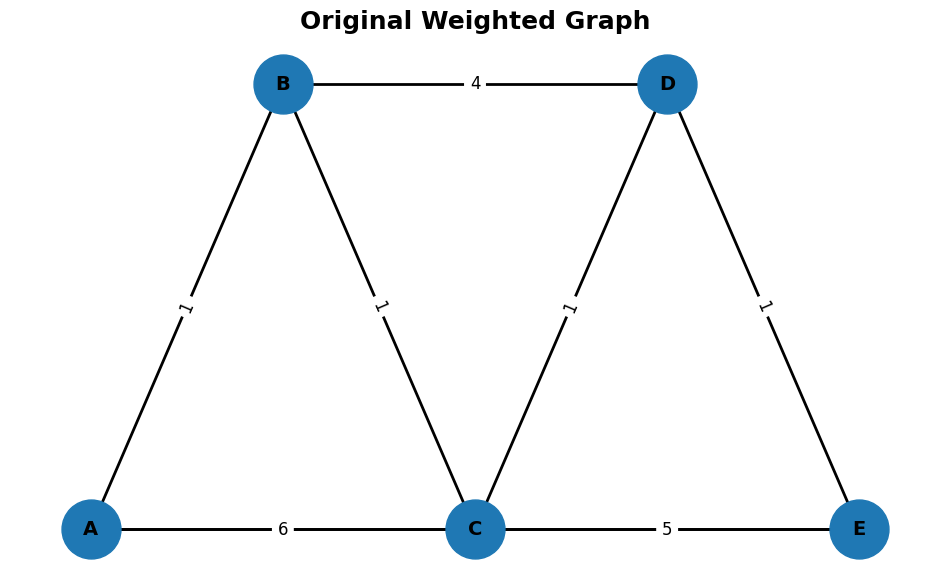



KRUSKAL'S ALGORITHM

Edges sorted by weight:

A - B = 1
B - C = 1
C - D = 1
D - E = 1
A - E = 3
B - D = 4
C - E = 5
A - C = 6

Greedy Selection Process:

SELECTED  : A - B = 1
SELECTED  : B - C = 1
SELECTED  : C - D = 1
SELECTED  : D - E = 1

----------------------------------------------------------------------
FINAL MST EDGES:
A - B = 1
B - C = 1
C - D = 1
D - E = 1

Total MST Cost = 4


STEP 3: KRUSKAL EDGE SELECTION GRAPH


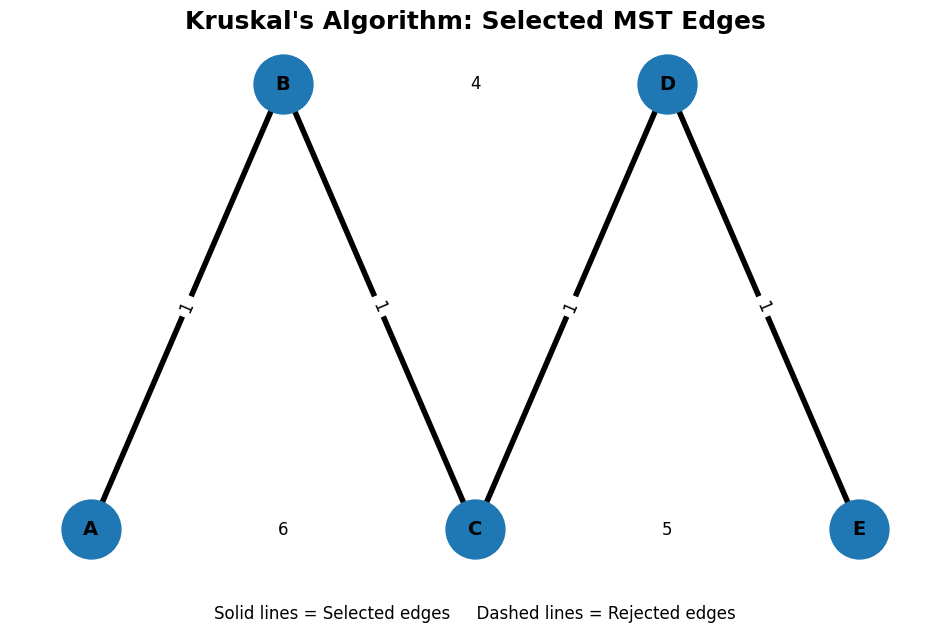



STEP 4: FINAL MINIMUM SPANNING TREE


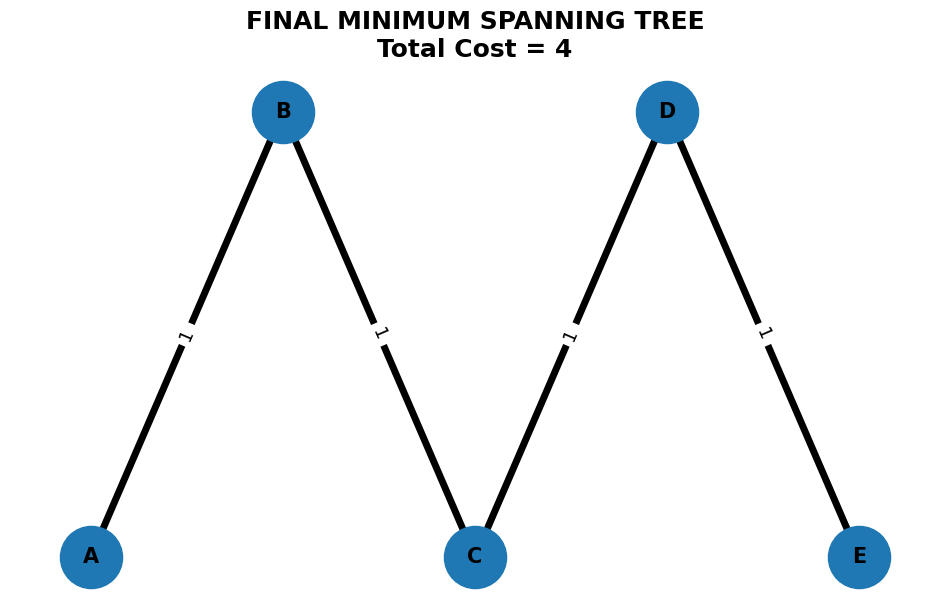



DIJKSTRA'S ALGORITHM

Source      : A
Destination : E

Greedy Selection Process:

Selected vertex: A (distance = 0)
  Updated B: 1
  Updated E: 3
  Updated C: 6
Selected vertex: B (distance = 1)
  Updated C: 2
  Updated D: 5
Selected vertex: C (distance = 2)
  Updated D: 3
Selected vertex: D (distance = 3)
Selected vertex: E (distance = 3)

----------------------------------------------------------------------
Shortest Path:
A -> E

Shortest Path Cost = 3


FINAL SHORTEST DISTANCES FROM SOURCE A
Vertex         Distance from A     
----------------------------------------
A              0                   
B              1                   
C              2                   
D              3                   
E              3                   


STEP 8: FINAL SHORTEST PATH DIAGRAM


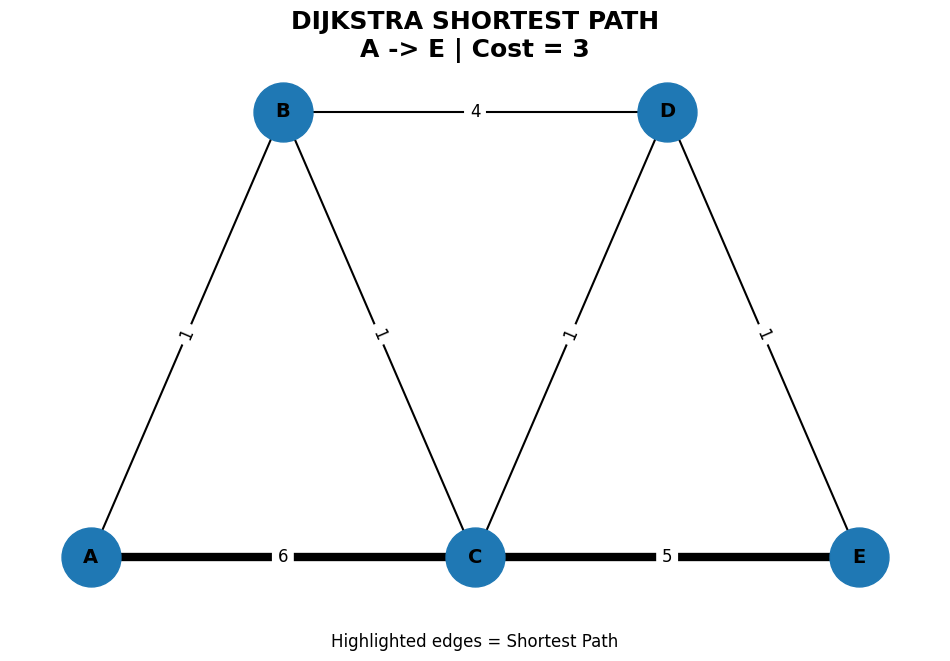



STEP 9: MST VS SHORTEST PATH GRAPH


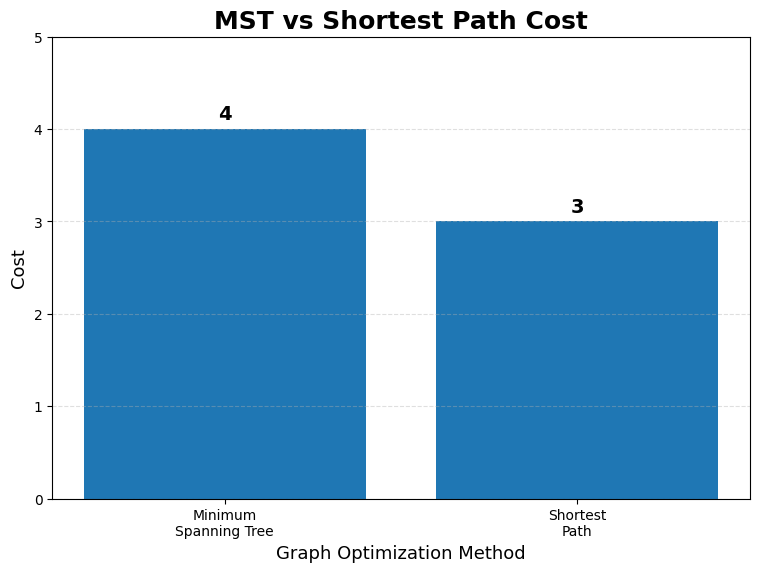



MST VS SHORTEST PATH - COMPARATIVE ANALYSIS
Parameter                     Minimum Spanning Tree         Shortest Path                 
------------------------------------------------------------------------------------------
Objective                     Connect all vertices          Minimum route between vertices
Algorithm                     Kruskal                       Dijkstra                      
Greedy Selection              Smallest safe edge            Nearest unvisited vertex      
Output                        Tree                          Path                          
Number of Edges               4                             1                             
Cost                          4                             3                             
Complexity                    O(E log E)                    O(V² + E)                     
Applications                  Network design                Navigation / routing          


GREEDY STRATEGY ANALYSIS

KRUSKAL'S ALGORI

In [4]:
# ================================================================
# Q39. MINIMUM SPANNING TREE VS SHORTEST PATH
# ================================================================

# ================================================================
# 1. IMPORT REQUIRED LIBRARIES
# ================================================================

import networkx as nx
import matplotlib.pyplot as plt
import heapq


# ================================================================
# 2. DEFINE THE GRAPH
# ================================================================

vertices = ['A', 'B', 'C', 'D', 'E']

edges = [
    ('A', 'B', 1),
    ('B', 'C', 1),
    ('C', 'D', 1),
    ('D', 'E', 1),
    ('A', 'E', 3),
    ('B', 'D', 4),
    ('C', 'E', 5),
    ('A', 'C', 6)
]

source = 'A'
destination = 'E'


# ================================================================
# 3. CREATE NETWORKX GRAPH
# ================================================================

G = nx.Graph()

G.add_nodes_from(vertices)

for u, v, weight in edges:
    G.add_edge(u, v, weight=weight)


# ================================================================
# 4. GRAPH POSITION
# ================================================================
# Fixed positions make all diagrams easy to understand.

pos = {
    'A': (0, 2),
    'B': (2, 3),
    'C': (4, 2),
    'D': (6, 3),
    'E': (8, 2)
}


# ================================================================
# 5. DISPLAY ORIGINAL WEIGHTED GRAPH
# ================================================================

def display_original_graph():

    plt.figure(figsize=(12, 7))

    # Draw vertices
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=1800
    )

    # Draw edges
    nx.draw_networkx_edges(
        G,
        pos,
        width=2
    )

    # Draw vertex labels
    nx.draw_networkx_labels(
        G,
        pos,
        font_size=14,
        font_weight='bold'
    )

    # Edge weight labels
    edge_labels = nx.get_edge_attributes(
        G,
        'weight'
    )

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=12
    )

    plt.title(
        "Original Weighted Graph",
        fontsize=18,
        fontweight='bold'
    )

    plt.axis('off')
    plt.show()


# ================================================================
# 6. DISJOINT SET / UNION-FIND
# ================================================================

class DisjointSet:

    def __init__(self, vertices):

        self.parent = {}
        self.rank = {}

        for vertex in vertices:

            self.parent[vertex] = vertex
            self.rank[vertex] = 0


    def find(self, vertex):

        if self.parent[vertex] != vertex:

            self.parent[vertex] = self.find(
                self.parent[vertex]
            )

        return self.parent[vertex]


    def union(self, vertex1, vertex2):

        root1 = self.find(vertex1)
        root2 = self.find(vertex2)

        if root1 == root2:

            return False

        if self.rank[root1] < self.rank[root2]:

            self.parent[root1] = root2

        elif self.rank[root1] > self.rank[root2]:

            self.parent[root2] = root1

        else:

            self.parent[root2] = root1
            self.rank[root1] += 1

        return True


# ================================================================
# 7. KRUSKAL'S ALGORITHM
# ================================================================

def kruskal_mst(vertices, edges):

    sorted_edges = sorted(
        edges,
        key=lambda x: x[2]
    )

    ds = DisjointSet(vertices)

    mst_edges = []
    rejected_edges = []

    total_cost = 0

    print("\n")
    print("=" * 70)
    print("KRUSKAL'S ALGORITHM")
    print("=" * 70)

    print("\nEdges sorted by weight:\n")

    for u, v, w in sorted_edges:

        print(
            f"{u} - {v} = {w}"
        )

    print("\nGreedy Selection Process:\n")

    for u, v, w in sorted_edges:

        if ds.union(u, v):

            mst_edges.append(
                (u, v, w)
            )

            total_cost += w

            print(
                f"SELECTED  : {u} - {v} = {w}"
            )

        else:

            rejected_edges.append(
                (u, v, w)
            )

            print(
                f"REJECTED  : {u} - {v} = {w} "
                f"(Cycle)"
            )

        if len(mst_edges) == len(vertices) - 1:

            break

    print("\n" + "-" * 70)

    print("FINAL MST EDGES:")

    for u, v, w in mst_edges:

        print(
            f"{u} - {v} = {w}"
        )

    print(
        f"\nTotal MST Cost = {total_cost}"
    )

    return mst_edges, rejected_edges, total_cost


# ================================================================
# 8. DISPLAY KRUSKAL SELECTION GRAPH
# ================================================================

def display_kruskal_selection(
        mst_edges,
        rejected_edges):

    plt.figure(figsize=(12, 7))

    # Draw all vertices
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=1800
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=14,
        font_weight='bold'
    )

    # Draw rejected edges using dashed lines
    rejected = [
        (u, v)
        for u, v, w in rejected_edges
    ]

    if rejected:

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=rejected,
            width=1.5,
            style='dashed'
        )

    # Draw selected MST edges
    selected = [
        (u, v)
        for u, v, w in mst_edges
    ]

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=selected,
        width=4
    )

    # All edge labels
    edge_labels = nx.get_edge_attributes(
        G,
        'weight'
    )

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=12
    )

    plt.title(
        "Kruskal's Algorithm: Selected MST Edges",
        fontsize=18,
        fontweight='bold'
    )

    plt.text(
        0.5,
        -0.08,
        "Solid lines = Selected edges     "
        "Dashed lines = Rejected edges",
        transform=plt.gca().transAxes,
        ha='center',
        fontsize=12
    )

    plt.axis('off')
    plt.show()


# ================================================================
# 9. FINAL MINIMUM SPANNING TREE DIAGRAM
# ================================================================

def display_final_mst(mst_edges, total_cost):

    MST = nx.Graph()

    MST.add_nodes_from(vertices)

    for u, v, w in mst_edges:

        MST.add_edge(
            u,
            v,
            weight=w
        )

    plt.figure(figsize=(12, 7))

    # Draw MST nodes
    nx.draw_networkx_nodes(
        MST,
        pos,
        node_size=2000
    )

    # Draw MST edges
    nx.draw_networkx_edges(
        MST,
        pos,
        width=5
    )

    # Draw labels
    nx.draw_networkx_labels(
        MST,
        pos,
        font_size=15,
        font_weight='bold'
    )

    # Draw weights
    mst_labels = nx.get_edge_attributes(
        MST,
        'weight'
    )

    nx.draw_networkx_edge_labels(
        MST,
        pos,
        edge_labels=mst_labels,
        font_size=13
    )

    plt.title(
        f"FINAL MINIMUM SPANNING TREE\n"
        f"Total Cost = {total_cost}",
        fontsize=18,
        fontweight='bold'
    )

    plt.axis('off')
    plt.show()


# ================================================================
# 10. BUILD ADJACENCY LIST FOR DIJKSTRA
# ================================================================

def build_adjacency_list(vertices, edges):

    graph = {
        vertex: []
        for vertex in vertices
    }

    for u, v, weight in edges:

        graph[u].append(
            (v, weight)
        )

        graph[v].append(
            (u, weight)
        )

    return graph


# ================================================================
# 11. DIJKSTRA'S ALGORITHM
# ================================================================

def dijkstra(graph, source, destination):

    distances = {
        vertex: float('inf')
        for vertex in graph
    }

    previous = {
        vertex: None
        for vertex in graph
    }

    visited = set()

    distances[source] = 0

    print("\n")
    print("=" * 70)
    print("DIJKSTRA'S ALGORITHM")
    print("=" * 70)

    print(
        f"\nSource      : {source}"
    )

    print(
        f"Destination : {destination}"
    )

    print("\nGreedy Selection Process:\n")

    while len(visited) < len(graph):

        current = None
        minimum_distance = float('inf')

        # Find nearest unvisited vertex
        for vertex in graph:

            if vertex not in visited:

                if distances[vertex] < minimum_distance:

                    minimum_distance = distances[vertex]
                    current = vertex

        if current is None:

            break

        visited.add(current)

        print(
            f"Selected vertex: {current} "
            f"(distance = {distances[current]})"
        )

        # Relax edges
        for neighbor, weight in graph[current]:

            if neighbor in visited:

                continue

            new_distance = (
                distances[current] + weight
            )

            if new_distance < distances[neighbor]:

                distances[neighbor] = new_distance
                previous[neighbor] = current

                print(
                    f"  Updated {neighbor}: "
                    f"{new_distance}"
                )

    # Reconstruct path
    path = []

    current = destination

    while current is not None:

        path.append(current)

        current = previous[current]

    path.reverse()

    if path[0] != source:

        return None, float('inf'), distances

    print("\n" + "-" * 70)

    print(
        "Shortest Path:"
    )

    print(
        " -> ".join(path)
    )

    print(
        f"\nShortest Path Cost = "
        f"{distances[destination]}"
    )

    return path, distances[destination], distances


# ================================================================
# 12. DISPLAY DIJKSTRA DISTANCES
# ================================================================

def display_dijkstra_distances(distances):

    print("\n")
    print("=" * 70)
    print("FINAL SHORTEST DISTANCES FROM SOURCE A")
    print("=" * 70)

    print(
        f"{'Vertex':<15}"
        f"{'Distance from A':<20}"
    )

    print("-" * 40)

    for vertex, distance in distances.items():

        print(
            f"{vertex:<15}"
            f"{distance:<20}"
        )


# ================================================================
# 13. FINAL SHORTEST PATH DIAGRAM
# ================================================================

def display_shortest_path(
        shortest_path,
        shortest_cost):

    plt.figure(figsize=(12, 7))

    # Draw all graph nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=1800
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=14,
        font_weight='bold'
    )

    # Draw all edges lightly
    nx.draw_networkx_edges(
        G,
        pos,
        width=1.5
    )

    # Shortest path edges
    path_edges = []

    for i in range(
        len(shortest_path) - 1
    ):

        path_edges.append(
            (
                shortest_path[i],
                shortest_path[i + 1]
            )
        )

    # Highlight shortest path
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=path_edges,
        width=6
    )

    # Edge weights
    edge_labels = nx.get_edge_attributes(
        G,
        'weight'
    )

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=12
    )

    plt.title(
        f"DIJKSTRA SHORTEST PATH\n"
        f"{' -> '.join(shortest_path)}"
        f" | Cost = {shortest_cost}",
        fontsize=18,
        fontweight='bold'
    )

    plt.text(
        0.5,
        -0.08,
        "Highlighted edges = Shortest Path",
        transform=plt.gca().transAxes,
        ha='center',
        fontsize=12
    )

    plt.axis('off')
    plt.show()


# ================================================================
# 14. COMPARISON BAR GRAPH
# ================================================================

def display_comparison_graph(
        mst_cost,
        shortest_cost):

    methods = [
        "Minimum\nSpanning Tree",
        "Shortest\nPath"
    ]

    costs = [
        mst_cost,
        shortest_cost
    ]

    plt.figure(figsize=(9, 6))

    bars = plt.bar(
        methods,
        costs
    )

    plt.ylabel(
        "Cost",
        fontsize=13
    )

    plt.xlabel(
        "Graph Optimization Method",
        fontsize=13
    )

    plt.title(
        "MST vs Shortest Path Cost",
        fontsize=18,
        fontweight='bold'
    )

    # Display values above bars
    for bar, value in zip(bars, costs):

        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            value + 0.1,
            str(value),
            ha='center',
            fontsize=14,
            fontweight='bold'
        )

    plt.ylim(
        0,
        max(costs) + 1
    )

    plt.grid(
        axis='y',
        linestyle='--',
        alpha=0.4
    )

    plt.show()


# ================================================================
# 15. COMPARISON TABLE
# ================================================================

def display_comparison_table(
        mst_edges,
        mst_cost,
        shortest_path,
        shortest_cost):

    print("\n")
    print("=" * 90)
    print("MST VS SHORTEST PATH - COMPARATIVE ANALYSIS")
    print("=" * 90)

    print(
        f"{'Parameter':<30}"
        f"{'Minimum Spanning Tree':<30}"
        f"{'Shortest Path':<30}"
    )

    print("-" * 90)

    print(
        f"{'Objective':<30}"
        f"{'Connect all vertices':<30}"
        f"{'Minimum route between vertices':<30}"
    )

    print(
        f"{'Algorithm':<30}"
        f"{'Kruskal':<30}"
        f"{'Dijkstra':<30}"
    )

    print(
        f"{'Greedy Selection':<30}"
        f"{'Smallest safe edge':<30}"
        f"{'Nearest unvisited vertex':<30}"
    )

    print(
        f"{'Output':<30}"
        f"{'Tree':<30}"
        f"{'Path':<30}"
    )

    print(
        f"{'Number of Edges':<30}"
        f"{len(mst_edges):<30}"
        f"{len(shortest_path)-1:<30}"
    )

    print(
        f"{'Cost':<30}"
        f"{mst_cost:<30}"
        f"{shortest_cost:<30}"
    )

    print(
        f"{'Complexity':<30}"
        f"{'O(E log E)':<30}"
        f"{'O(V² + E)':<30}"
    )

    print(
        f"{'Applications':<30}"
        f"{'Network design':<30}"
        f"{'Navigation / routing':<30}"
    )

    print("=" * 90)


# ================================================================
# 16. GREEDY STRATEGY COMPARISON
# ================================================================

def display_greedy_analysis():

    print("\n")
    print("=" * 80)
    print("GREEDY STRATEGY ANALYSIS")
    print("=" * 80)

    print("\nKRUSKAL'S ALGORITHM")
    print("-" * 50)

    print(
        "1. Sort all edges by increasing weight."
    )

    print(
        "2. Select the smallest edge."
    )

    print(
        "3. Reject the edge if it creates a cycle."
    )

    print(
        "4. Continue until V-1 edges are selected."
    )

    print(
        "\nGreedy choice:"
    )

    print(
        "Choose the smallest safe edge."
    )

    print("\nDIJKSTRA'S ALGORITHM")
    print("-" * 50)

    print(
        "1. Start from the source vertex."
    )

    print(
        "2. Set source distance to zero."
    )

    print(
        "3. Select the unvisited vertex with "
        "smallest tentative distance."
    )

    print(
        "4. Relax its neighboring edges."
    )

    print(
        "5. Repeat until the required path is obtained."
    )

    print(
        "\nGreedy choice:"
    )

    print(
        "Choose the closest unvisited vertex."
    )


# ================================================================
# 17. CRITICAL EVALUATION
# ================================================================

def display_critical_evaluation():

    print("\n")
    print("=" * 80)
    print("CRITICAL EVALUATION")
    print("=" * 80)

    print("\nMinimum Spanning Tree - Advantages")
    print("-" * 50)

    print(
        "• Minimizes total cost of connecting all vertices."
    )

    print(
        "• Avoids unnecessary cycles."
    )

    print(
        "• Useful for network infrastructure design."
    )

    print(
        "• Kruskal works well for sparse graphs."
    )

    print("\nMinimum Spanning Tree - Limitations")
    print("-" * 50)

    print(
        "• Does not guarantee the shortest route "
        "between two vertices."
    )

    print(
        "• Requires a connected graph for a complete MST."
    )

    print("\nShortest Path - Advantages")
    print("-" * 50)

    print(
        "• Finds minimum-cost route between vertices."
    )

    print(
        "• Useful for navigation and routing."
    )

    print(
        "• Dijkstra is efficient for non-negative weights."
    )

    print("\nShortest Path - Limitations")
    print("-" * 50)

    print(
        "• Dijkstra cannot correctly handle negative "
        "edge weights."
    )

    print(
        "• It does not minimize the cost of connecting "
        "the entire graph."
    )


# ================================================================
# 18. SYNTHESIS AND INSIGHTS
# ================================================================

def display_insights(
        mst_cost,
        shortest_cost):

    print("\n")
    print("=" * 80)
    print("SYNTHESIS AND INSIGHTS")
    print("=" * 80)

    print("\n1. Different Optimization Objectives")

    print(
        "MST minimizes the total cost required to "
        "connect every vertex."
    )

    print(
        "Shortest Path minimizes the cost of travelling "
        "between selected vertices."
    )

    print("\n2. Different Greedy Decisions")

    print(
        "Kruskal selects the smallest safe edge."
    )

    print(
        "Dijkstra selects the closest unvisited vertex."
    )

    print("\n3. Different Outputs")

    print(
        f"MST Cost = {mst_cost}"
    )

    print(
        f"Shortest Path Cost = {shortest_cost}"
    )

    print(
        "\nThe shortest path cost can be smaller than "
        "the total MST cost because they solve different "
        "optimization objectives."
    )

    print("\n4. Algorithm Selection")

    print(
        "Use MST algorithms when the goal is minimum-cost "
        "network construction."
    )

    print(
        "Use shortest-path algorithms when the goal is "
        "minimum-cost travel or routing."
    )


# ================================================================
# 19. MAIN PROGRAM
# ================================================================

print("\n")
print("=" * 90)
print("MINIMUM SPANNING TREE VS SHORTEST PATH")
print("GREEDY ALGORITHM COMPARISON")
print("=" * 90)

print(
    "\nCourse: Design and Analysis of Algorithms"
)

print(
    "Course Code: CSA06"
)

print(
    "CO4: Solve optimization problems using "
    "Dynamic Programming and Greedy Strategies"
)


# ================================================================
# STEP 1 - ORIGINAL GRAPH
# ================================================================

print("\n\nSTEP 1: DISPLAYING ORIGINAL GRAPH")

display_original_graph()


# ================================================================
# STEP 2 - KRUSKAL
# ================================================================

mst_edges, rejected_edges, mst_cost = kruskal_mst(
    vertices,
    edges
)


# ================================================================
# STEP 3 - KRUSKAL GRAPH
# ================================================================

print("\n\nSTEP 3: KRUSKAL EDGE SELECTION GRAPH")

display_kruskal_selection(
    mst_edges,
    rejected_edges
)


# ================================================================
# STEP 4 - FINAL MST
# ================================================================

print("\n\nSTEP 4: FINAL MINIMUM SPANNING TREE")

display_final_mst(
    mst_edges,
    mst_cost
)


# ================================================================
# STEP 5 - BUILD ADJACENCY LIST
# ================================================================

graph = build_adjacency_list(
    vertices,
    edges
)


# ================================================================
# STEP 6 - DIJKSTRA
# ================================================================

shortest_path, shortest_cost, distances = dijkstra(
    graph,
    source,
    destination
)


# ================================================================
# STEP 7 - DISPLAY DISTANCES
# ================================================================

display_dijkstra_distances(
    distances
)


# ================================================================
# STEP 8 - SHORTEST PATH DIAGRAM
# ================================================================

print("\n\nSTEP 8: FINAL SHORTEST PATH DIAGRAM")

display_shortest_path(
    shortest_path,
    shortest_cost
)


# ================================================================
# STEP 9 - COMPARISON GRAPH
# ================================================================

print("\n\nSTEP 9: MST VS SHORTEST PATH GRAPH")

display_comparison_graph(
    mst_cost,
    shortest_cost
)


# ================================================================
# STEP 10 - COMPARISON TABLE
# ================================================================

display_comparison_table(
    mst_edges,
    mst_cost,
    shortest_path,
    shortest_cost
)


# ================================================================
# STEP 11 - GREEDY ANALYSIS
# ================================================================

display_greedy_analysis()


# ================================================================
# STEP 12 - CRITICAL EVALUATION
# ================================================================

display_critical_evaluation()


# ================================================================
# STEP 13 - SYNTHESIS AND INSIGHTS
# ================================================================

display_insights(
    mst_cost,
    shortest_cost
)


# ================================================================
# FINAL RESULT
# ================================================================

print("\n")
print("=" * 90)
print("FINAL RESULT")
print("=" * 90)

print("\nMinimum Spanning Tree:")

for u, v, w in mst_edges:

    print(
        f"{u} - {v} = {w}"
    )

print(
    f"\nTotal MST Cost = {mst_cost}"
)

print(
    "\nShortest Path:"
)

print(
    " -> ".join(shortest_path)
)

print(
    f"\nShortest Path Cost = {shortest_cost}"
)

print("\n" + "-" * 90)

print(
    "CONCLUSION:"
)

print(
    "MST minimizes the total cost of connecting "
    "all vertices."
)

print(
    "Shortest Path minimizes the cost between "
    "a selected source and destination."
)

print(
    "Therefore, MST and Shortest Path are different "
    "graph optimization problems even though both "
    "can use greedy strategies."
)

print("=" * 90)